# 01 — EDA & Text Preprocessing
**Proyek:** Analisis Sentimen & Emosi Ulasan E-Commerce Bahasa Indonesia  
**Dataset:** PRDECT-ID Dataset  
**Tim:** Crazy Rich Team — PBA 2026

---
| Tahap | Isi |
|-------|-----|
| Load Data | Baca CSV, validasi tipe data, cek missing & duplikat |
| EDA | Distribusi label, statistik teks, WordCloud, n-gram |
| Preprocessing & Export | `TextPreprocessor`, apply, simpan ke `data/clean/` |

---
## ⚙️ Setup Environment

In [1]:
# ── Install library yang mungkin belum tersedia ──────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for lib in ["PySastrawi", "wordcloud", "emoji", "nltk", "matplotlib", "seaborn", "tqdm"]:
    try:
        import importlib
        importlib.import_module(lib.lower().replace("pysastrawi", "Sastrawi"))
    except ImportError:
        install(lib)

print("✅ Semua library siap.")

✅ Semua library siap.


In [2]:
# ── Import global ─────────────────────────────────────────────────────────────
import os
import re
import string
import warnings
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import emoji
import nltk
from wordcloud import WordCloud, STOPWORDS
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings("ignore")

# Download NLTK data (tokenizer)
nltk.download("punkt",       quiet=True)
nltk.download("punkt_tab",   quiet=True)
nltk.download("stopwords",   quiet=True)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

# ── Seed untuk reproducibility ────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Path konstanta ────────────────────────────────────────────────────────────
BASE_DIR      = Path(".")                          # root repo
RAW_PATH      = BASE_DIR / "PRDECT-ID Dataset.csv"
CLEAN_DIR     = BASE_DIR / "data" / "clean"
CLEAN_PATH    = CLEAN_DIR / "cleaned_dataset.csv"
FIG_DIR       = BASE_DIR / "data" / "figures"

for d in [CLEAN_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("📂 Direktori output:")
print(f"   Clean CSV : {CLEAN_PATH.resolve()}")
print(f"   Figures   : {FIG_DIR.resolve()}")

📂 Direktori output:
   Clean CSV : D:\pba2026-crazyrichteam\data\clean\cleaned_dataset.csv
   Figures   : D:\pba2026-crazyrichteam\data\figures


---
# 📦 PROSES 1 — Load Data
> Membaca dataset raw dan memvalidasi schema


## 1.1 Baca CSV

In [3]:
df_raw = pd.read_csv(RAW_PATH, sep=";", encoding="utf-8")

print(f"✅ Dataset berhasil dibaca.")
print(f"   Baris    : {df_raw.shape[0]:,}")
print(f"   Kolom    : {df_raw.shape[1]}")
print(f"   Kolom    : {df_raw.columns.tolist()}")
df_raw.head(5)

✅ Dataset berhasil dibaca.
   Baris    : 5,400
   Kolom    : 11
   Kolom    : ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion']


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


## 1.2 Tipe Data & Schema

In [4]:
# Ringkasan schema
schema = pd.DataFrame({
    "dtype"      : df_raw.dtypes,
    "non_null"   : df_raw.notna().sum(),
    "null"       : df_raw.isna().sum(),
    "null_%"     : (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    "unique"     : df_raw.nunique(),
    "sample"     : df_raw.iloc[0]
})
schema

,dtype,non_null,null,null_%,unique,sample
Category,object,5400,0,0.00,29,Computers and Laptops
Product Name,object,5400,0,0.00,1308,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...
Location,object,5400,0,0.00,61,Jakarta Utara
Price,int64,5400,0,0.00,555,53500
Overall Rating,float64,5400,0,0.00,10,4.9
Number Sold,int64,5400,0,0.00,1043,5449
Total Review,int64,5400,0,0.00,958,2369
Customer Rating,int64,5400,0,0.00,5,5
Customer Review,object,5400,0,0.00,5305,Alhamdulillah berfungsi dengan baik. Packaging...
Sentiment,object,5398,2,0.04,2,Positive


## 1.3 Cek Missing Values

In [5]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({"Count": missing, "Percentage (%)": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0]

if missing_df.empty:
    print("✅ Tidak ada missing values.")
else:
    print(f"⚠️  Ditemukan missing values pada {len(missing_df)} kolom:")
    display(missing_df)

# Tampilkan baris dengan missing
df_raw[df_raw.isnull().any(axis=1)]

⚠️  Ditemukan missing values pada 2 kolom:


,Count,Percentage (%)
Sentiment,2,0.04
Emotion,2,0.04


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
2556,Kitchen,Tefal Cook & Clean Frypan 26cm Wajan Anti Lengket,Kab. Tangerang,419000,4.9,2792,1454,4,"rekomended seller, barang sesuai deskripsi tingga",NaN,NaN
3840,Household,Lemari Plastik Pakaian DIY / Wardrobe / Rak Ba...,Jakarta Barat,596000,4.6,2353,1409,1,"pengiriman cepat namun, saya baru sempat susun...",NaN,NaN


## 1.4 Cek Duplikat

In [6]:
n_dup = df_raw.duplicated().sum()
n_dup_review = df_raw.duplicated(subset=["Customer Review"]).sum()

print(f"Duplikat full-row       : {n_dup}")
print(f"Duplikat 'Customer Review': {n_dup_review}")

if n_dup > 0:
    print("\nContoh duplikat:")
    display(df_raw[df_raw.duplicated(keep=False)].sort_values("Customer Review").head(10))

Duplikat full-row       : 7
Duplikat 'Customer Review': 95

Contoh duplikat:


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
835,Automotive,Hayaidesu Keychain Gantungan Kunci Aksesoris V...,Jakarta Selatan,25000,4.9,7884,4399,5,Produk sesuai deskripsi??. Variasi produk bera...,Positive,Happy
839,Automotive,Hayaidesu Keychain Gantungan Kunci Aksesoris V...,Jakarta Selatan,25000,4.9,7884,4399,5,Produk sesuai deskripsi??. Variasi produk bera...,Positive,Happy
2196,Sport,5-60kg Adjustable Handgrip Hand Grip Alat Fitn...,Jakarta Barat,16200,4.9,6323,768,1,"barang tidak ada, komplain tidak direspon...pe...",Negative,Fear
2197,Sport,5-60kg Adjustable Handgrip Hand Grip Alat Fitn...,Jakarta Barat,16200,4.9,6323,768,1,"barang tidak ada, komplain tidak direspon...pe...",Negative,Fear
2198,Sport,5-60kg Adjustable Handgrip Hand Grip Alat Fitn...,Jakarta Barat,16200,4.9,6323,768,1,"barang tidak ada, komplain tidak direspon...pe...",Negative,Fear
720,Office & Stationery,( ISI 30 Roll) Kertas Print Kasir thermal pape...,Kota Tangerang Selatan,58500,4.9,2294,795,5,belanja disini mantap pengiriman cepat dan bar...,Positive,Love
723,Office & Stationery,( ISI 30 Roll) Kertas Print Kasir thermal pape...,Kota Tangerang Selatan,58500,4.9,2294,795,5,belanja disini mantap pengiriman cepat dan bar...,Positive,Love
27,Computers and Laptops,cooling pad laptop tahan 24 jam 6.000 Rpm angi...,Kota Surabaya,385000,5.0,2716,1843,5,"mantap kipasnya kenceng, barangnya berkualitas...",Positive,Happy
29,Computers and Laptops,cooling pad laptop tahan 24 jam 6.000 Rpm angi...,Kota Surabaya,385000,5.0,2716,1843,5,"mantap kipasnya kenceng, barangnya berkualitas...",Positive,Happy
290,Toys and Hobbies,Kereta Thomas Mainan Thomas,Kota Tangerang,59000,4.7,37200,11900,1,saya belom menerima paket ini kenapa sudah sel...,Negative,Anger


## 1.5 Working Copy — Drop Missing & Duplikat

In [7]:
df = df_raw.copy()

# Drop baris dimana label target NaN
df.dropna(subset=["Sentiment", "Emotion", "Customer Review"], inplace=True)

# Drop full-row duplikat
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Shape setelah cleaning awal : {df.shape}")
print(f"Baris dihapus               : {len(df_raw) - len(df)}")

Shape setelah cleaning awal : (5391, 11)
Baris dihapus               : 9


---
# 📊 COMMIT 2 — Exploratory Data Analysis (EDA)
> **Git message:** `feat(eda): add distribution plots, text stats, wordcloud, and ngram analysis`

## 2.1 Distribusi Label Sentimen & Emosi

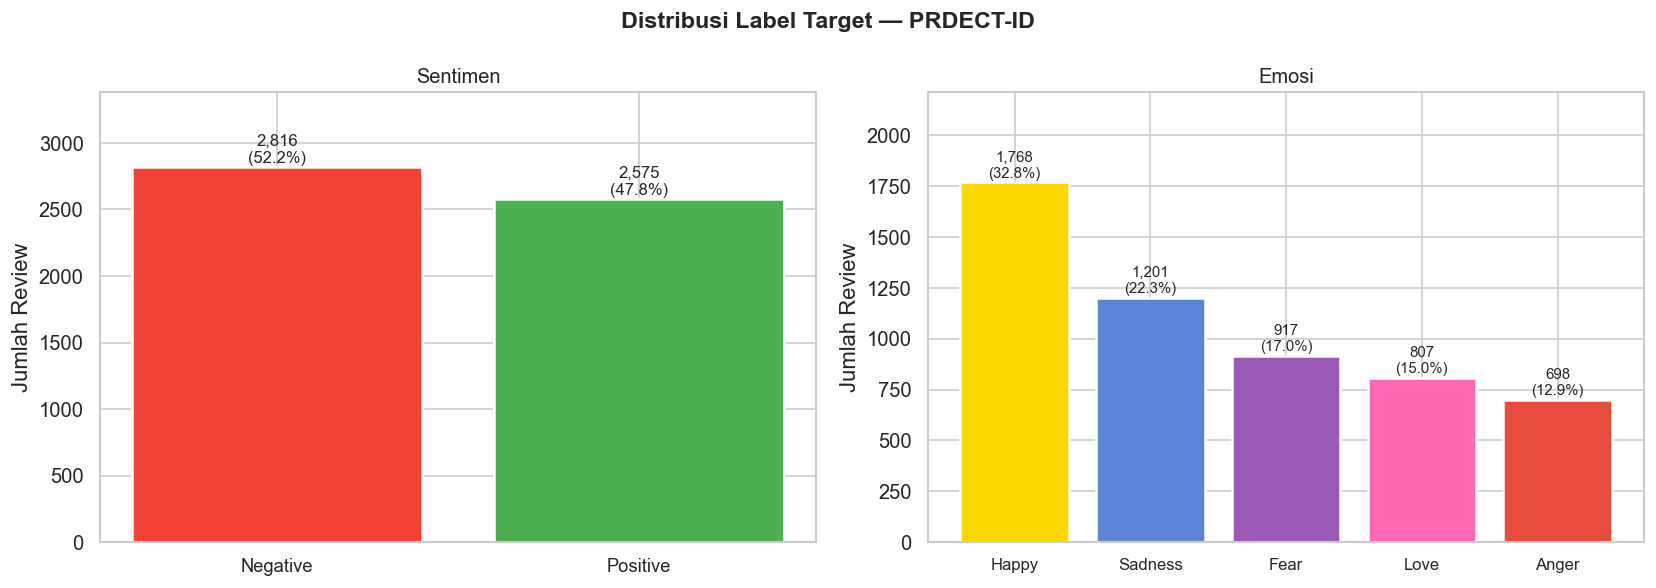

💾 Saved: 01_label_distribution.png


In [8]:
SENTIMENT_PALETTE = {"Positive": "#4CAF50", "Negative": "#F44336"}
EMOTION_PALETTE   = {
    "Happy"  : "#FFD700",
    "Sadness": "#5C85D6",
    "Fear"   : "#9B59B6",
    "Love"   : "#FF69B4",
    "Anger"  : "#E74C3C",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Label Target — PRDECT-ID", fontsize=14, fontweight="bold")

# ── Sentimen ────────────────────────────────────────────────────────────────
sent_counts = df["Sentiment"].value_counts()
colors_s    = [SENTIMENT_PALETTE[k] for k in sent_counts.index]
bars = axes[0].bar(sent_counts.index, sent_counts.values, color=colors_s, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, sent_counts.values):
    pct = val / sent_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Sentimen", fontsize=12)
axes[0].set_ylabel("Jumlah Review")
axes[0].set_ylim(0, sent_counts.max() * 1.2)
axes[0].tick_params(axis="x", labelsize=11)

# ── Emosi ───────────────────────────────────────────────────────────────────
emo_counts = df["Emotion"].value_counts()
colors_e   = [EMOTION_PALETTE.get(k, "#95A5A6") for k in emo_counts.index]
bars2 = axes[1].bar(emo_counts.index, emo_counts.values, color=colors_e, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars2, emo_counts.values):
    pct = val / emo_counts.sum() * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Emosi", fontsize=12)
axes[1].set_ylabel("Jumlah Review")
axes[1].set_ylim(0, emo_counts.max() * 1.25)
axes[1].tick_params(axis="x", labelsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_label_distribution.png", bbox_inches="tight")
plt.show()
print("💾 Saved: 01_label_distribution.png")

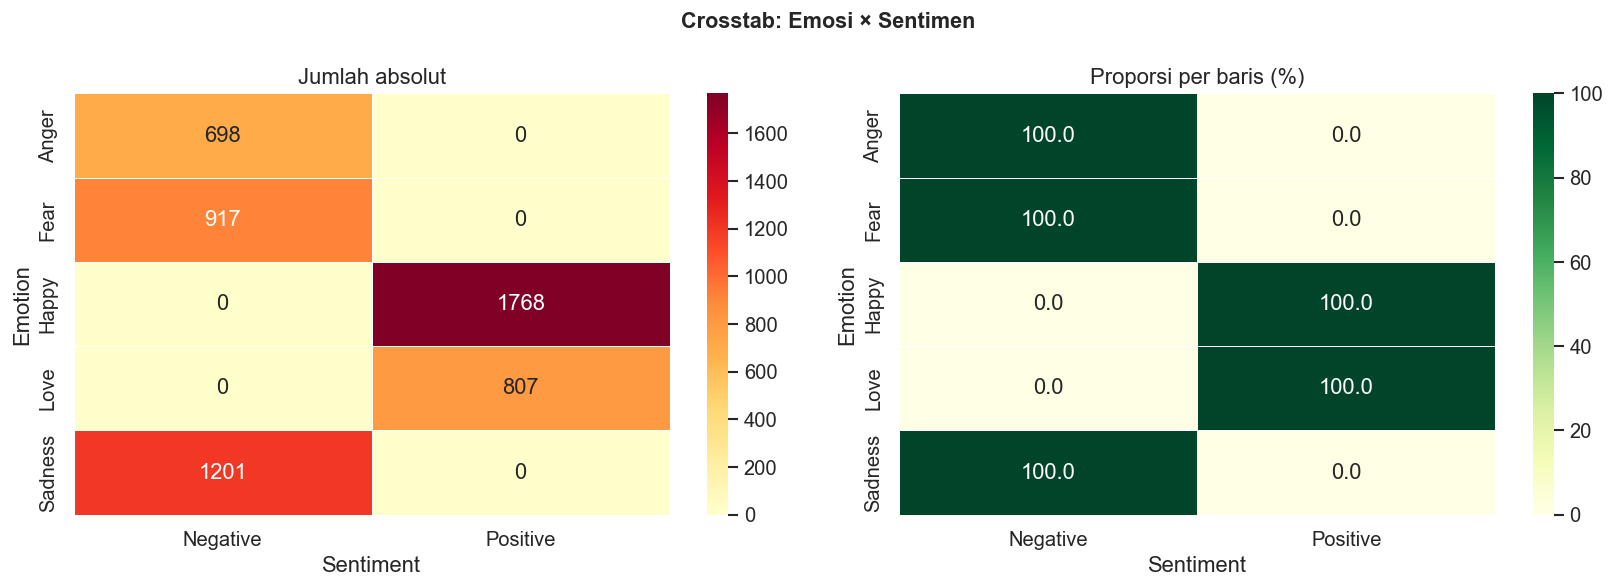

In [9]:
# ── Crosstab Sentimen × Emosi ─────────────────────────────────────────────
ct = pd.crosstab(df["Emotion"], df["Sentiment"])
ct_pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Crosstab: Emosi × Sentimen", fontsize=13, fontweight="bold")

sns.heatmap(ct,     annot=True, fmt="d",    cmap="YlOrRd", ax=axes[0], linewidths=0.5)
axes[0].set_title("Jumlah absolut")

sns.heatmap(ct_pct, annot=True, fmt=".1f", cmap="YlGn",  ax=axes[1], linewidths=0.5)
axes[1].set_title("Proporsi per baris (%)")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_emotion_sentiment_crosstab.png", bbox_inches="tight")
plt.show()

## 2.2 Distribusi Kategori Produk

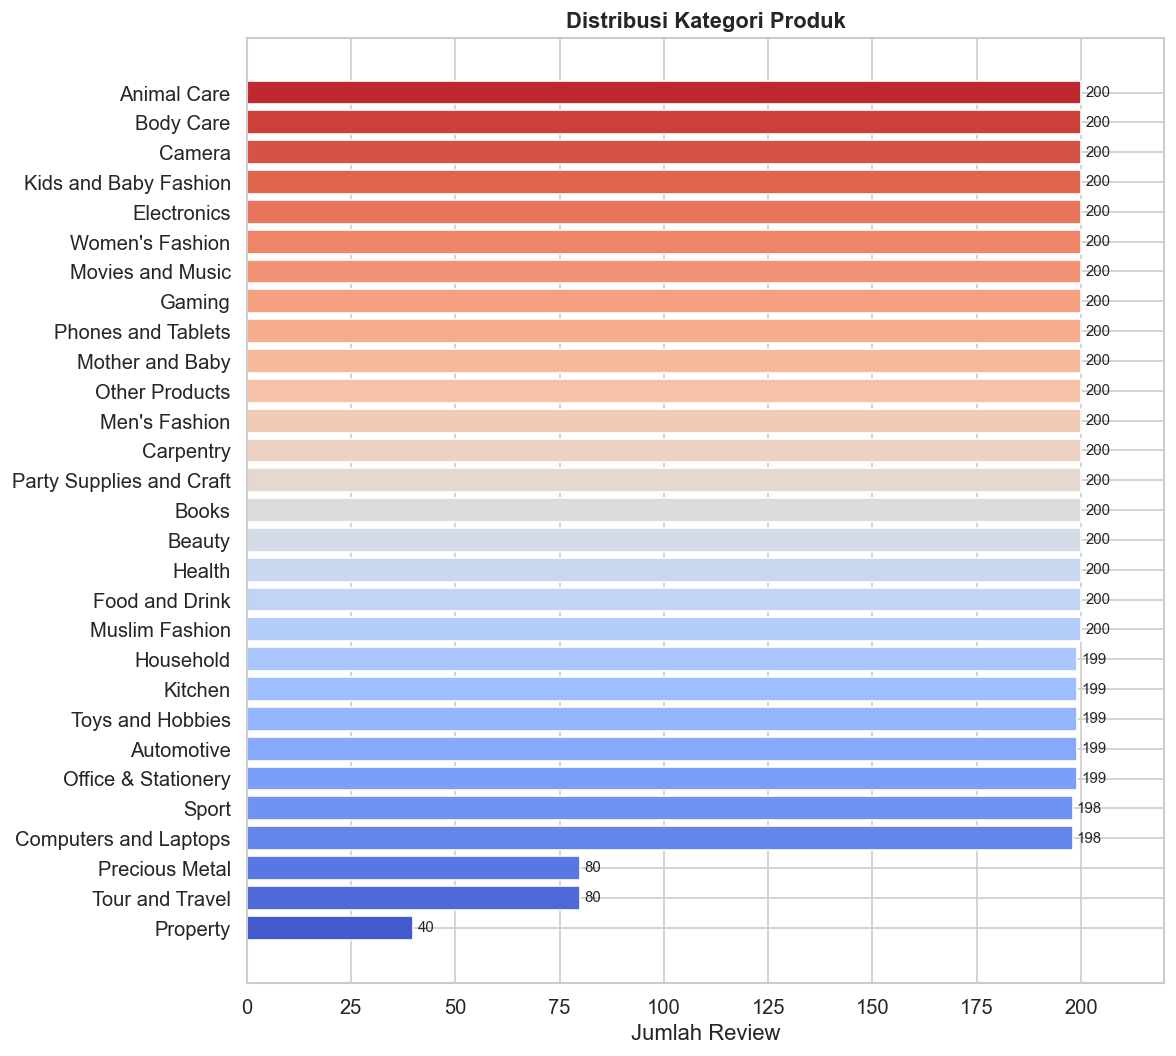

In [10]:
cat_counts = df["Category"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(cat_counts.index, cat_counts.values,
               color=sns.color_palette("coolwarm", len(cat_counts)))
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{val}", va="center", fontsize=9)
ax.set_xlabel("Jumlah Review")
ax.set_title("Distribusi Kategori Produk", fontweight="bold")
ax.set_xlim(0, cat_counts.max() * 1.1)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_category_distribution.png", bbox_inches="tight")
plt.show()

## 2.3 Statistik Panjang Teks

In [11]:
df["char_len"]  = df["Customer Review"].str.len()
df["word_len"]  = df["Customer Review"].str.split().str.len()

print("📏 Statistik Panjang Review (karakter):")
display(df["char_len"].describe().to_frame("char_len").T)

print("\n📏 Statistik Panjang Review (kata):")
display(df["word_len"].describe().to_frame("word_len").T)

📏 Statistik Panjang Review (karakter):


,count,mean,std,min,25%,50%,75%,max
char_len,5391.0,103.762011,98.192265,3.0,44.0,78.0,128.0,1058.0



📏 Statistik Panjang Review (kata):


,count,mean,std,min,25%,50%,75%,max
word_len,5391.0,16.089779,15.639151,1.0,7.0,12.0,20.0,184.0


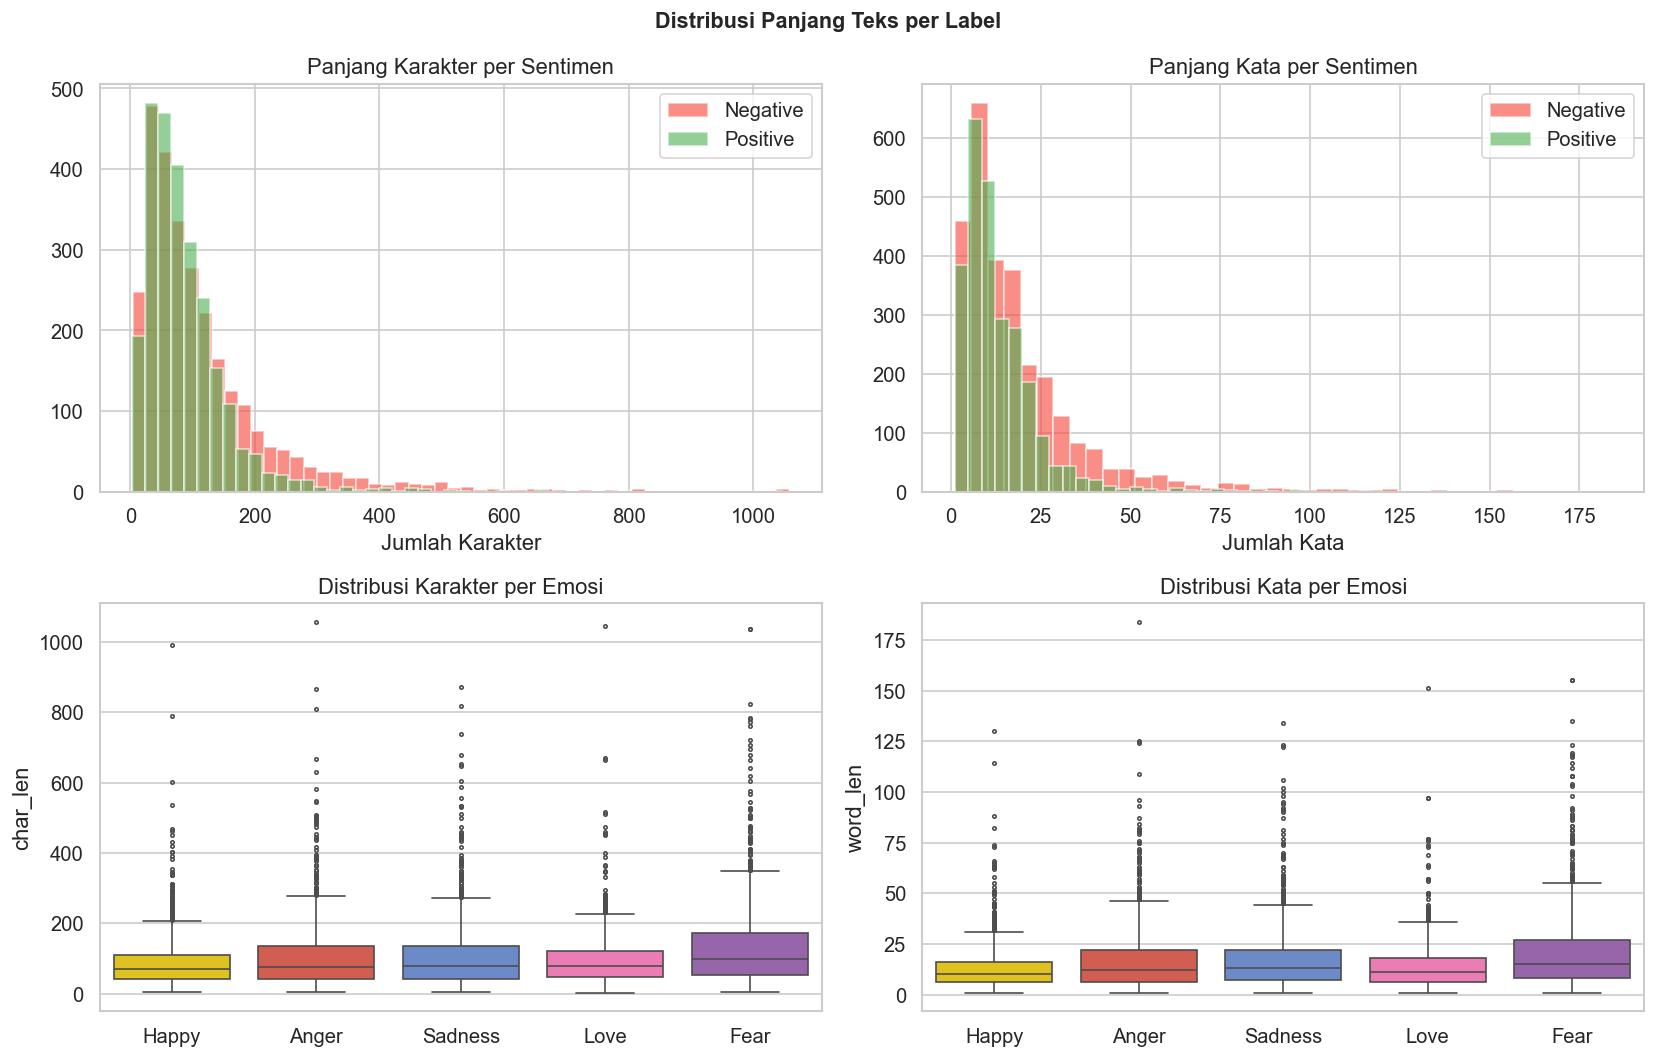

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Distribusi Panjang Teks per Label", fontsize=13, fontweight="bold")

# Char len per Sentiment
for label, grp in df.groupby("Sentiment"):
    axes[0,0].hist(grp["char_len"], bins=50, alpha=0.6,
                   label=label, color=SENTIMENT_PALETTE[label])
axes[0,0].set_title("Panjang Karakter per Sentimen")
axes[0,0].set_xlabel("Jumlah Karakter")
axes[0,0].legend()

# Word len per Sentiment
for label, grp in df.groupby("Sentiment"):
    axes[0,1].hist(grp["word_len"], bins=40, alpha=0.6,
                   label=label, color=SENTIMENT_PALETTE[label])
axes[0,1].set_title("Panjang Kata per Sentimen")
axes[0,1].set_xlabel("Jumlah Kata")
axes[0,1].legend()

# Boxplot char per Emotion
emotion_order = df.groupby("Emotion")["char_len"].median().sort_values().index
df_plot = df[df["Emotion"].isin(EMOTION_PALETTE.keys())]
sns.boxplot(data=df_plot, x="Emotion", y="char_len",
            order=emotion_order, palette=EMOTION_PALETTE,
            ax=axes[1,0], fliersize=2)
axes[1,0].set_title("Distribusi Karakter per Emosi")
axes[1,0].set_xlabel("")

# Boxplot word per Emotion
sns.boxplot(data=df_plot, x="Emotion", y="word_len",
            order=emotion_order, palette=EMOTION_PALETTE,
            ax=axes[1,1], fliersize=2)
axes[1,1].set_title("Distribusi Kata per Emosi")
axes[1,1].set_xlabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_text_length_distribution.png", bbox_inches="tight")
plt.show()

## 2.4 Frekuensi Kata & N-Gram

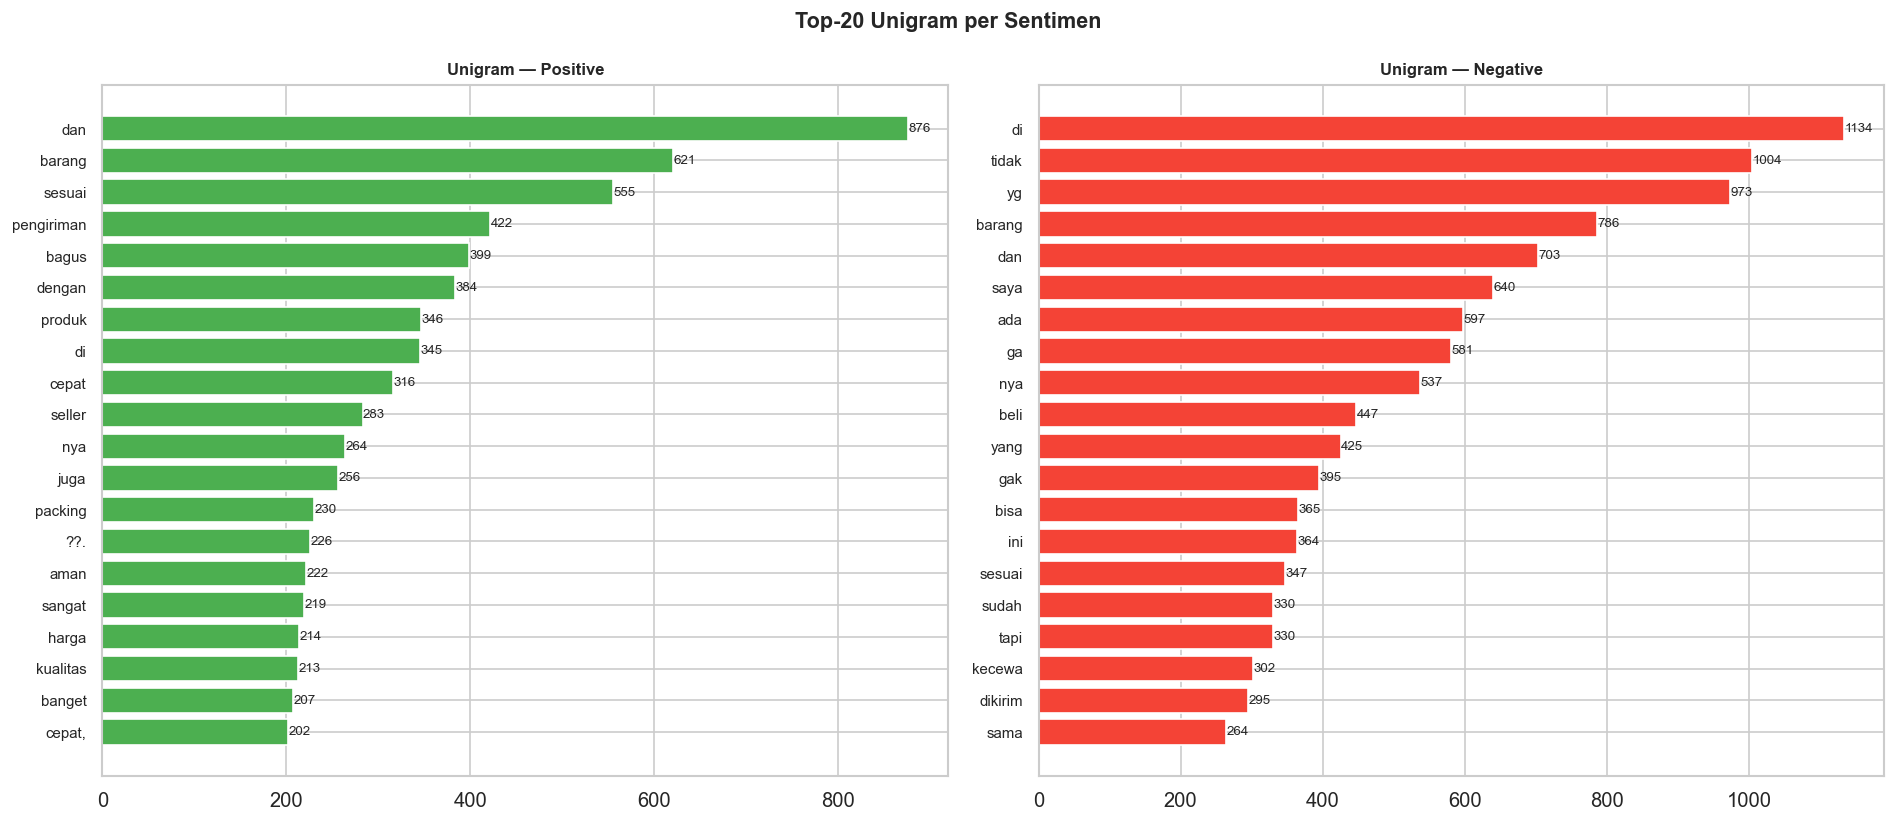

In [13]:
def get_top_ngrams(series: pd.Series, n: int = 1, top_k: int = 20) -> list:
    """Hitung frekuensi n-gram dari Series teks."""
    from nltk.util import ngrams as nltk_ngrams
    counter = Counter()
    for text in series.dropna():
        tokens = str(text).lower().split()
        if n == 1:
            counter.update(tokens)
        else:
            counter.update([" ".join(g) for g in nltk_ngrams(tokens, n)])
    return counter.most_common(top_k)

def plot_ngrams(ax, ngram_data, title, color):
    labels, values = zip(*ngram_data)
    y_pos = range(len(labels))
    ax.barh(list(y_pos), values, color=color, edgecolor="white")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight="bold")
    for i, v in enumerate(values):
        ax.text(v + 0.5, i, str(v), va="center", fontsize=8)

# ── Top 20 Unigram Positif vs Negatif ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Top-20 Unigram per Sentimen", fontsize=13, fontweight="bold")

for ax, sent, col in zip(axes, ["Positive", "Negative"], ["#4CAF50", "#F44336"]):
    corpus = df[df["Sentiment"] == sent]["Customer Review"]
    top = get_top_ngrams(corpus, n=1, top_k=20)
    plot_ngrams(ax, top, f"Unigram — {sent}", col)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_top_unigram_sentiment.png", bbox_inches="tight")
plt.show()

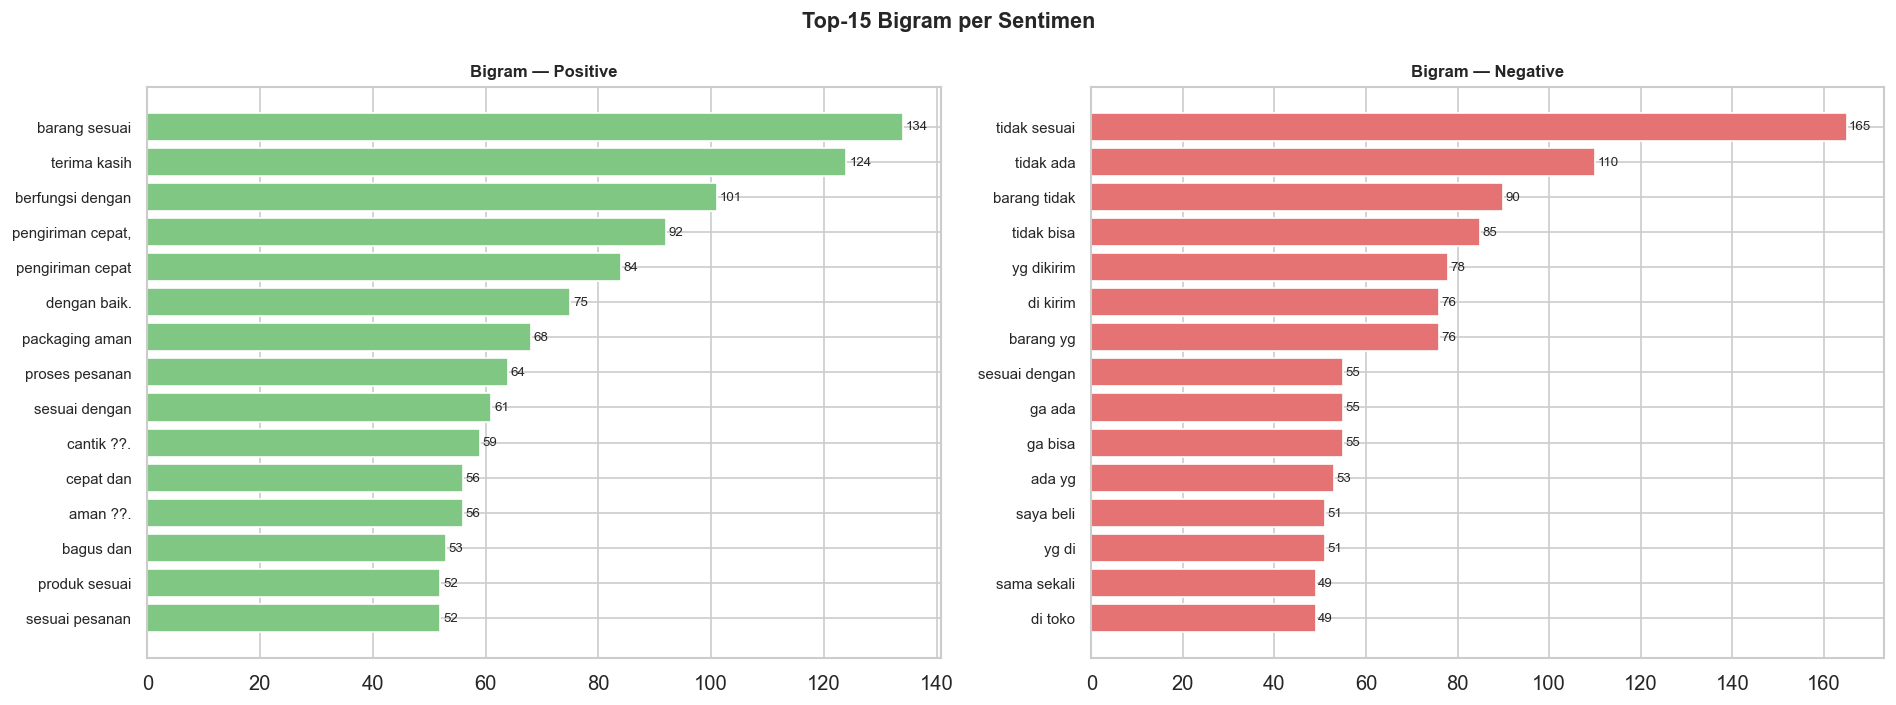

In [14]:
# ── Top-15 Bigram ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top-15 Bigram per Sentimen", fontsize=13, fontweight="bold")

for ax, sent, col in zip(axes, ["Positive", "Negative"], ["#81C784", "#E57373"]):
    corpus = df[df["Sentiment"] == sent]["Customer Review"]
    top = get_top_ngrams(corpus, n=2, top_k=15)
    plot_ngrams(ax, top, f"Bigram — {sent}", col)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_top_bigram_sentiment.png", bbox_inches="tight")
plt.show()

## 2.5 Word Cloud

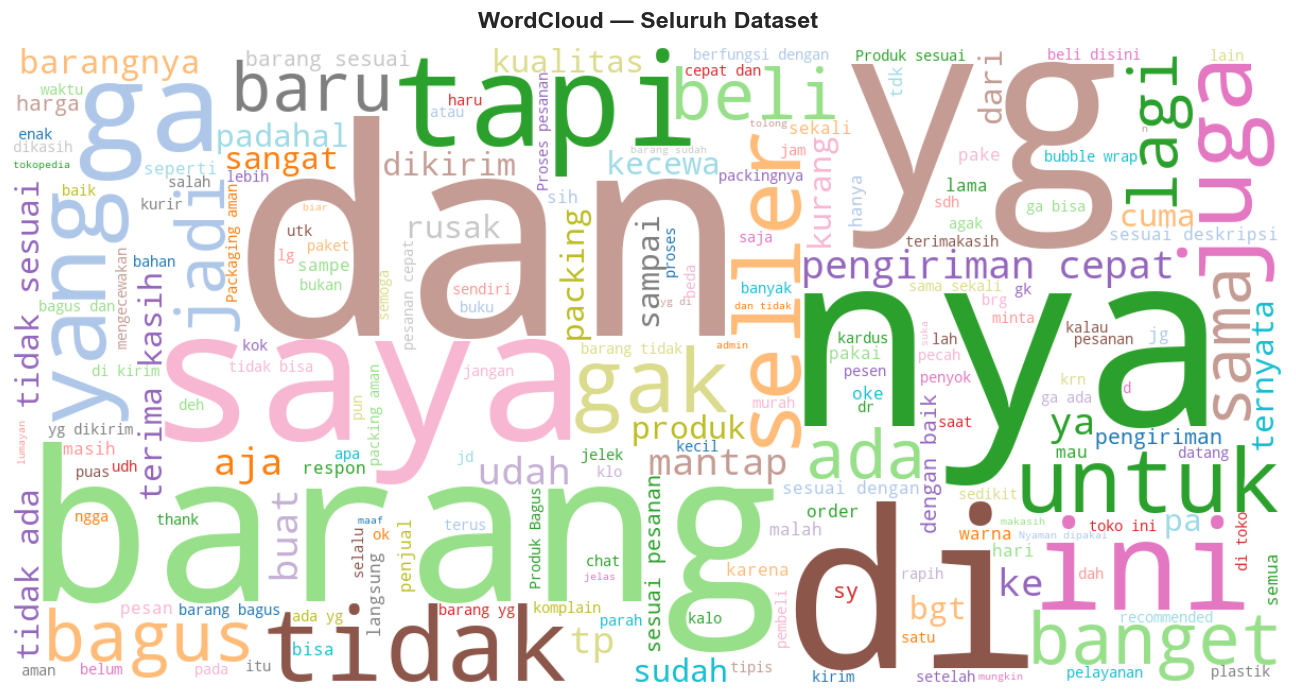

In [15]:
# ── WordCloud Keseluruhan ─────────────────────────────────────────────────
all_text = " ".join(df["Customer Review"].dropna().astype(str).tolist())

wc_all = WordCloud(
    width=1200, height=600, background_color="white",
    max_words=200, colormap="tab20",
    random_state=RANDOM_SEED
).generate(all_text)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc_all, interpolation="bilinear")
ax.axis("off")
ax.set_title("WordCloud — Seluruh Dataset", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_wordcloud_all.png", bbox_inches="tight")
plt.show()

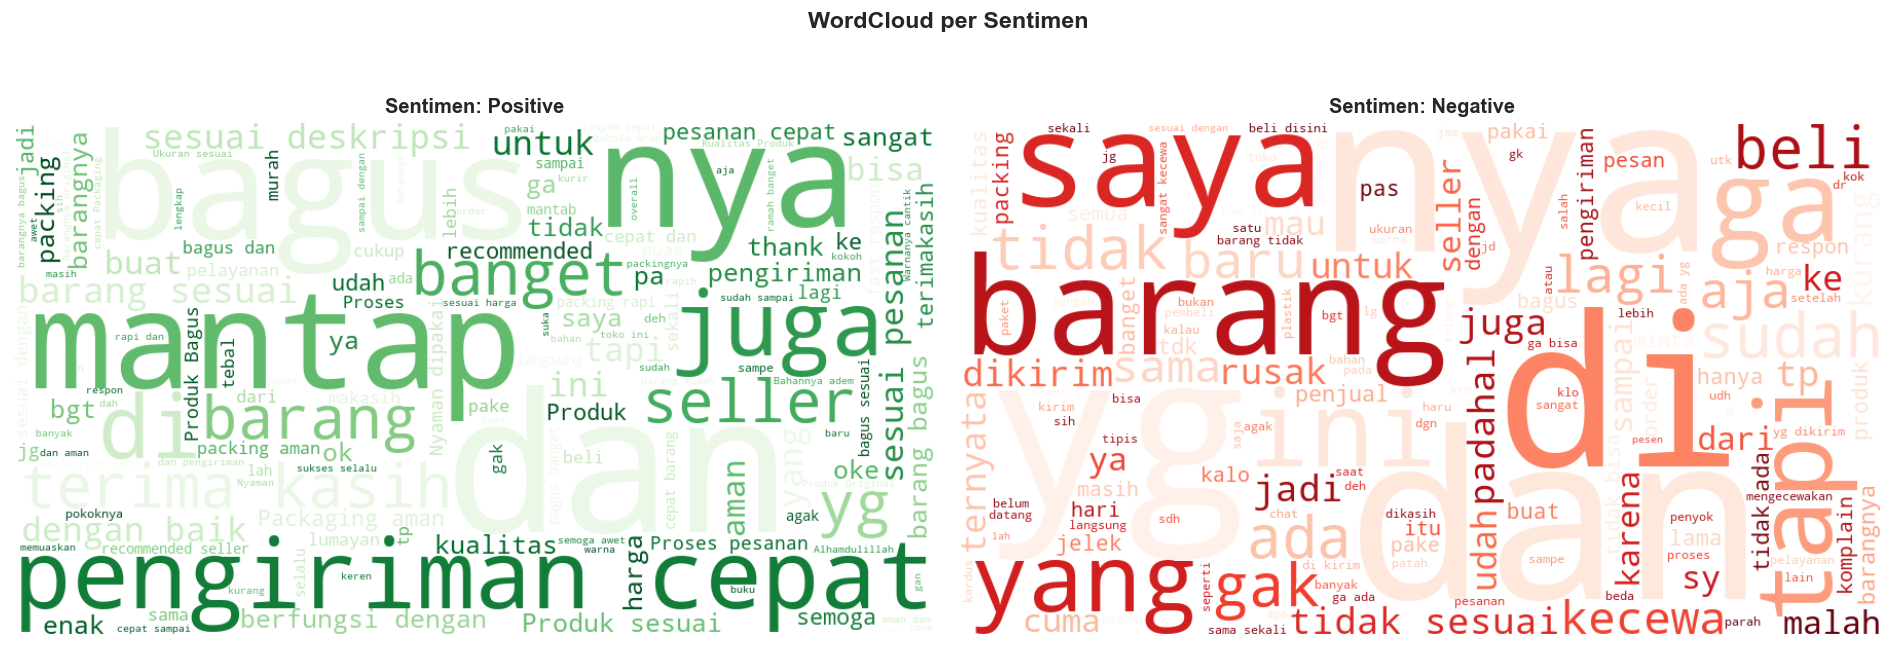

In [16]:
# ── WordCloud per Sentimen ────────────────────────────────────────────────
SENT_CMAP = {"Positive": "Greens", "Negative": "Reds"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("WordCloud per Sentimen", fontsize=14, fontweight="bold")

for ax, sent in zip(axes, ["Positive", "Negative"]):
    text = " ".join(df[df["Sentiment"] == sent]["Customer Review"].dropna().astype(str))
    wc = WordCloud(
        width=900, height=500, background_color="white",
        max_words=150, colormap=SENT_CMAP[sent],
        random_state=RANDOM_SEED
    ).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Sentimen: {sent}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "08_wordcloud_per_sentiment.png", bbox_inches="tight")
plt.show()

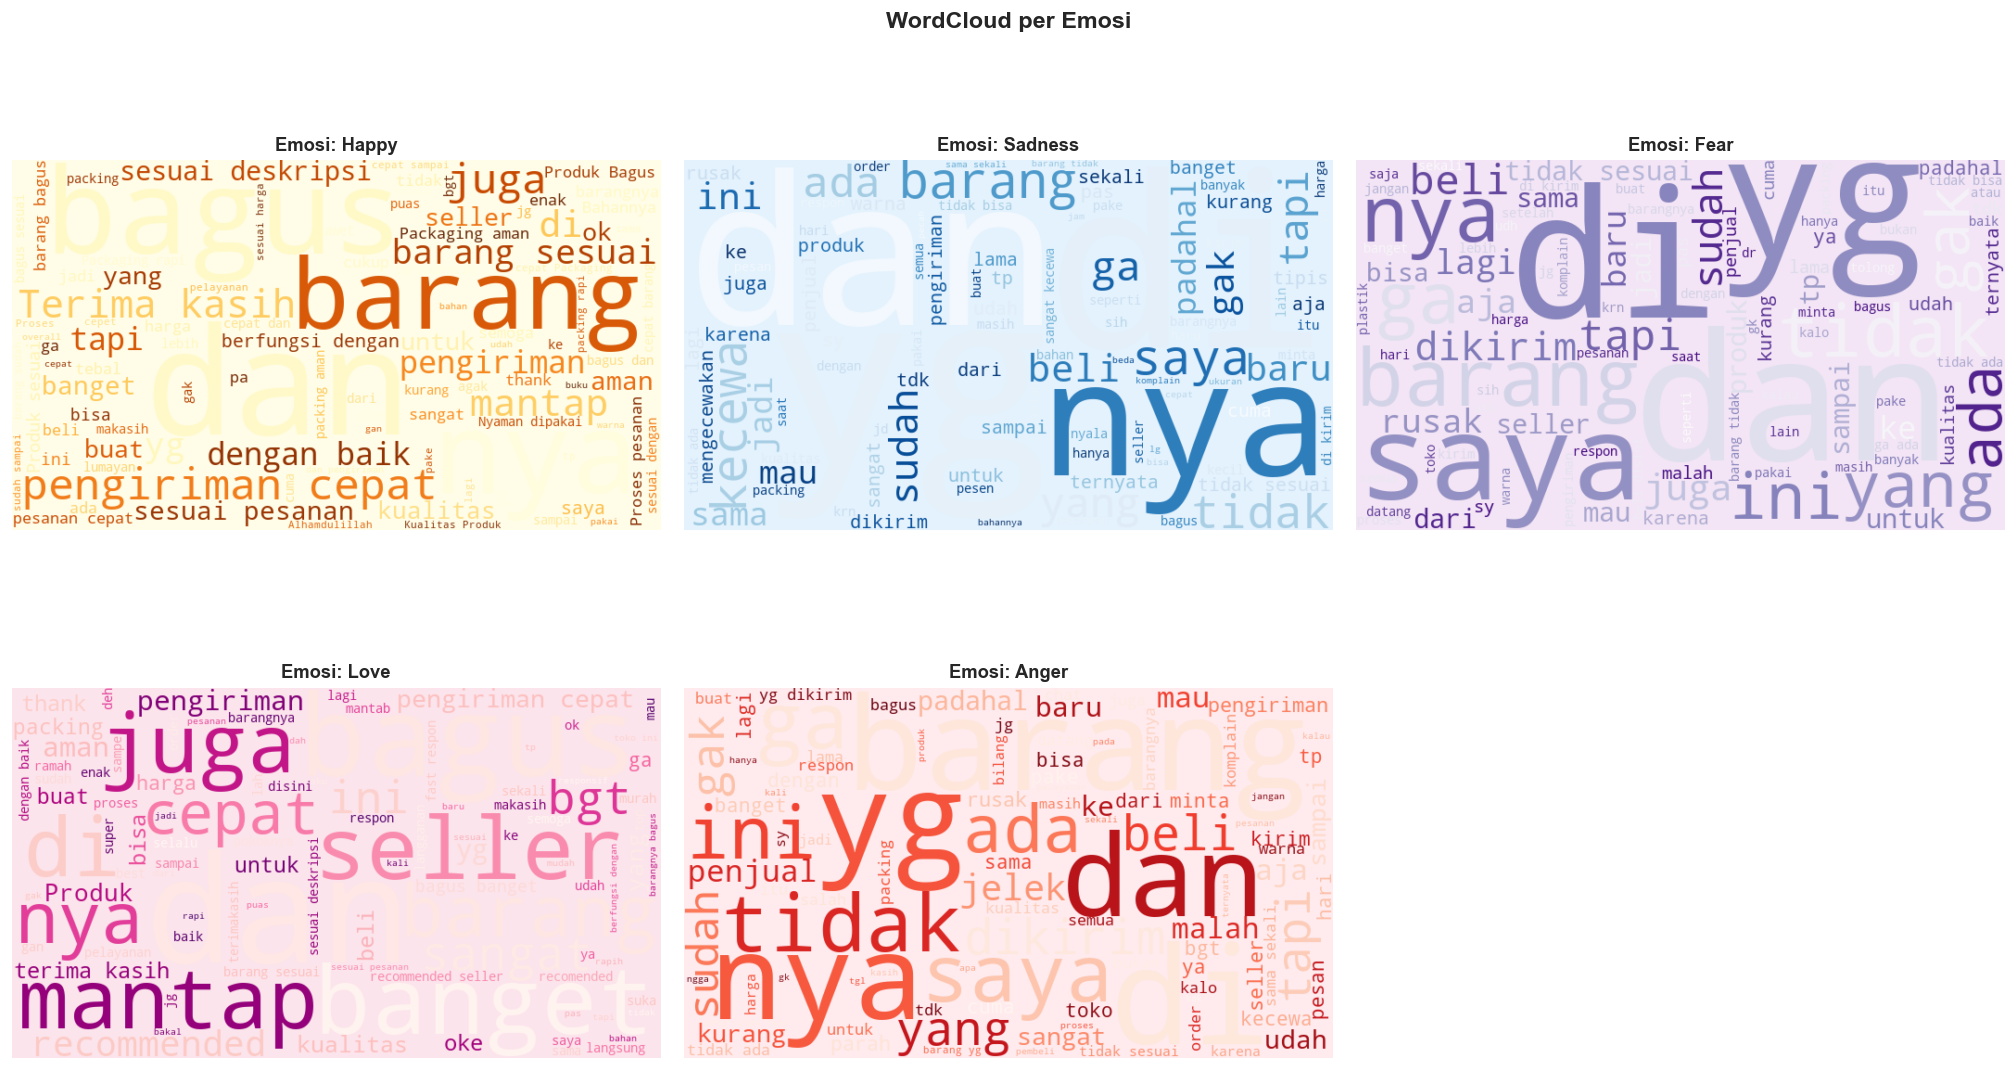

In [17]:
# ── WordCloud per Emosi ───────────────────────────────────────────────────
EMO_BG = {"Happy": "#FFFDE7", "Sadness": "#E3F2FD",
           "Fear" : "#F3E5F5", "Love"   : "#FCE4EC", "Anger": "#FFEBEE"}
EMO_CM = {"Happy": "YlOrBr", "Sadness": "Blues",
           "Fear" : "Purples", "Love"  : "RdPu",   "Anger": "Reds"}

emotions = df["Emotion"].value_counts().index.tolist()
ncols = 3
nrows = (len(emotions) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(17, 5 * nrows))
fig.suptitle("WordCloud per Emosi", fontsize=14, fontweight="bold")
axes_flat = axes.flatten() if nrows > 1 else axes

for idx, emo in enumerate(emotions):
    text = " ".join(df[df["Emotion"] == emo]["Customer Review"].dropna().astype(str))
    wc = WordCloud(
        width=700, height=400,
        background_color=EMO_BG.get(emo, "white"),
        max_words=100, colormap=EMO_CM.get(emo, "viridis"),
        random_state=RANDOM_SEED
    ).generate(text)
    axes_flat[idx].imshow(wc, interpolation="bilinear")
    axes_flat[idx].axis("off")
    axes_flat[idx].set_title(f"Emosi: {emo}", fontsize=11, fontweight="bold")

# Sembunyikan subplot kosong
for j in range(len(emotions), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "09_wordcloud_per_emotion.png", bbox_inches="tight")
plt.show()

## 2.6 Analisis Emoji & Karakter Khusus

In [18]:
def extract_emojis(text: str) -> list:
    """Ekstrak semua emoji dari string."""
    return [ch for ch in str(text) if ch in emoji.EMOJI_DATA]

df["emojis"]      = df["Customer Review"].apply(extract_emojis)
df["emoji_count"] = df["emojis"].str.len()

print(f"Review mengandung emoji : {(df['emoji_count'] > 0).sum():,} ({(df['emoji_count'] > 0).mean()*100:.1f}%)")
print(f"Rata-rata emoji/review  : {df['emoji_count'].mean():.2f}")

# Top emoji
all_emojis  = [e for lst in df["emojis"] for e in lst]
top_emojis  = Counter(all_emojis).most_common(15)

if top_emojis:
    emo_chars, emo_counts = zip(*top_emojis)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(emo_chars)), emo_counts,
           color=sns.color_palette("husl", len(emo_chars)))
    ax.set_xticks(range(len(emo_chars)))
    ax.set_xticklabels(list(emo_chars), fontsize=14)
    ax.set_ylabel("Frekuensi")
    ax.set_title("Top-15 Emoji Paling Sering Muncul", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "10_top_emoji.png", bbox_inches="tight")
    plt.show()
else:
    print("ℹ️  Tidak ditemukan emoji dalam dataset.")

Review mengandung emoji : 0 (0.0%)
Rata-rata emoji/review  : 0.00
ℹ️  Tidak ditemukan emoji dalam dataset.


## 2.7 Ringkasan Temuan EDA

In [19]:
sent_ratio = df["Sentiment"].value_counts(normalize=True).mul(100).round(1)
emo_ratio  = df["Emotion"].value_counts(normalize=True).mul(100).round(1)

print("=" * 55)
print("              RINGKASAN TEMUAN EDA")
print("=" * 55)
print(f" Total sampel        : {len(df):,}")
print(f" Total kategori      : {df['Category'].nunique()}")
print(f" Median panjang teks : {df['char_len'].median():.0f} karakter / {df['word_len'].median():.0f} kata")
print(f" Max panjang teks    : {df['char_len'].max()} karakter")
print()
print(" Sentimen (%)        :")
for k, v in sent_ratio.items():
    bar = "█" * int(v / 3)
    print(f"   {k:<12} {v:5.1f}%  {bar}")
print()
print(" Emosi (%)           :")
for k, v in emo_ratio.items():
    bar = "█" * int(v / 3)
    print(f"   {k:<12} {v:5.1f}%  {bar}")
print()
print(f" Review beremoji     : {(df['emoji_count'] > 0).sum():,}")
print("=" * 55)
print()
print("⚠️  CATATAN UNTUK PREPROCESSING:")
print("  1. Dataset sedikit imbalanced (Negative > Positive)")
print("  2. Emosi sangat imbalanced (Happy >> Anger)")
print("  3. Banyak slang Indonesia + campur kode Inggris")
print("  4. Ada karakter repetisi (bagussss)")
print("  5. Perlu normalisasi singkatan (bgt, yg, dll)")

              RINGKASAN TEMUAN EDA
 Total sampel        : 5,391
 Total kategori      : 29
 Median panjang teks : 78 karakter / 12 kata
 Max panjang teks    : 1058 karakter

 Sentimen (%)        :
   Negative      52.2%  █████████████████
   Positive      47.8%  ███████████████

 Emosi (%)           :
   Happy         32.8%  ██████████
   Sadness       22.3%  ███████
   Fear          17.0%  █████
   Love          15.0%  █████
   Anger         12.9%  ████

 Review beremoji     : 0

⚠️  CATATAN UNTUK PREPROCESSING:
  1. Dataset sedikit imbalanced (Negative > Positive)
  2. Emosi sangat imbalanced (Happy >> Anger)
  3. Banyak slang Indonesia + campur kode Inggris
  4. Ada karakter repetisi (bagussss)
  5. Perlu normalisasi singkatan (bgt, yg, dll)


---
# 🧹 COMMIT 3 — Preprocessing & Export
> **Git message:** `feat(preprocessing): add TextPreprocessor class with slang normalization, stemming, and export clean CSV`

## 3.1 Kamus Slang E-Commerce Indonesia

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Kamus normalisasi slang & singkatan khas ulasan e-commerce Indonesia
# Sumber: gabungan dari colloquial-indonesian-lexicon + penambahan manual
# ─────────────────────────────────────────────────────────────────────────────
SLANG_DICT: dict[str, str] = {
    # ── Negasi & kata umum ──────────────────────────────────────────────────
    "gak"     : "tidak",    "ga"      : "tidak",    "nggak"   : "tidak",
    "ngga"    : "tidak",    "g"       : "tidak",    "tdk"     : "tidak",
    "tak"     : "tidak",    "blm"     : "belum",    "udah"    : "sudah",
    "udh"     : "sudah",    "sdh"     : "sudah",    "dah"     : "sudah",
    "emg"     : "memang",   "emang"   : "memang",   "hrs"     : "harus",
    "bs"      : "bisa",     "bsa"     : "bisa",     "bgt"     : "banget",
    "bngt"    : "banget",   "bener"   : "benar",    "bner"    : "benar",
    "aja"     : "saja",     "doang"   : "saja",     "dong"    : "lah",
    "sih"     : "",         "deh"     : "",         "kok"     : "",

    # ── Kata ganti & preposisi ───────────────────────────────────────────────
    "yg"      : "yang",     "yng"     : "yang",     "dr"      : "dari",
    "dgn"     : "dengan",   "dng"     : "dengan",   "utk"     : "untuk",
    "tuk"     : "untuk",    "pd"      : "pada",     "krn"     : "karena",
    "karna"   : "karena",   "krena"   : "karena",   "sm"      : "sama",
    "jg"      : "juga",     "juga"    : "juga",     "tp"      : "tapi",
    "tpi"     : "tapi",     "klo"     : "kalau",    "klu"     : "kalau",
    "kalo"    : "kalau",    "klw"     : "kalau",    "kmrn"    : "kemarin",
    "skrg"    : "sekarang", "bsk"     : "besok",    "dll"     : "dan lain lain",
    "dsb"     : "dan sebagainya",

    # ── Kata sifat & kualitas produk ─────────────────────────────────────────
    "mantep"  : "mantap",   "mantul"  : "mantap",   "keren"   : "bagus",
    "oke"     : "baik",     "ok"      : "baik",     "oce"     : "baik",
    "sip"     : "bagus",    "jos"     : "bagus",    "joss"    : "bagus",
    "top"     : "bagus",    "kece"    : "bagus",    "kinclong": "bersih",
    "sesuai"  : "sesuai",   "cocok"   : "sesuai",   "mulus"   : "mulus",
    "ori"     : "original", "orisinil": "original", "asli"    : "original",
    "murah"   : "murah",    "mura"    : "murah",    "mahal"   : "mahal",
    "jelek"   : "buruk",    "rusak"   : "rusak",    "cacat"   : "cacat",
    "puas"    : "puas",     "kecewa"  : "kecewa",   "kzl"     : "kesal",

    # ── Pengiriman & transaksi ───────────────────────────────────────────────
    "penjual" : "penjual",  "seller"  : "penjual",  "toko"    : "toko",
    "respon"  : "respons",  "fast"    : "cepat",    "slow"    : "lambat",
    "packing" : "kemasan",  "pake"    : "pakai",    "dipake"  : "dipakai",
    "cod"     : "bayar ditempat", "ongkir" : "ongkos kirim",
    "rekomen" : "rekomendasi", "rekomend": "rekomendasi",

    # ── Ekspresi & interjeksi ────────────────────────────────────────────────
    "alhamdulillah": "alhamdulillah",  # Pertahankan
    "wkwk"    : "",     "haha"    : "",     "hehe"    : "",
    "lol"     : "",     "btw"     : "ngomong ngomong",
    "makasih" : "terima kasih",  "makasi"  : "terima kasih",
    "thx"     : "terima kasih",  "thanks"  : "terima kasih",
    "tq"      : "terima kasih",  "ty"      : "terima kasih",
    "trims"   : "terima kasih",  "tks"     : "terima kasih",

    # ── Ukuran & satuan ──────────────────────────────────────────────────────
    "rb"      : "ribu",    "jt"      : "juta",     "k"       : "ribu",
    "cm"      : "sentimeter", "mm"   : "milimeter",
}

print(f"✅ Kamus slang dimuat: {len(SLANG_DICT)} entri")

✅ Kamus slang dimuat: 111 entri


## 3.2 Kelas TextPreprocessor

In [21]:
class TextPreprocessor:
    """
    Preprocessing teks komprehensif untuk ulasan e-commerce berbahasa Indonesia.

    Pipeline (berurutan):
    1.  Lowercase
    2.  Hapus URL
    3.  Hapus HTML tags
    4.  Konversi emoji → teks deskriptif
    5.  Normalisasi angka harga (50k, 100rb)
    6.  Hapus tanda baca & karakter non-alfanumerik
    7.  Normalisasi karakter repetisi ("bagussss" → "bagus")
    8.  Normalisasi slang menggunakan SLANG_DICT
    9.  Hapus stopword (Sastrawi + NLTK Indonesia)
    10. Stemming (Sastrawi MorphologicalAnalyzer)
    11. Normalisasi whitespace & strip
    """

    # Regex yang dikompilasi sekali untuk efisiensi
    _RE_URL          = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
    _RE_HTML         = re.compile(r"<[^>]+>")
    _RE_PRICE_K      = re.compile(r"(\d+)[kK]\b")      # 50k → 50 ribu
    _RE_PRICE_RB     = re.compile(r"(\d+)\s*rb\b")     # 100rb → 100 ribu
    _RE_PRICE_JT     = re.compile(r"(\d+)\s*jt\b")     # 2jt → 2 juta
    _RE_PRICE_RP     = re.compile(r"[Rr][Pp]\.?\s*\d[\d.,]*") # Rp50.000
    _RE_NUMBER       = re.compile(r"\d+")
    _RE_PUNCT        = re.compile(r"[^\w\s]")           # non-word non-space
    _RE_UNDERSCORE   = re.compile(r"_+")
    _RE_REPEAT_CHAR  = re.compile(r"(.)\1{2,}")        # ≥3 karakter sama
    _RE_WHITESPACE   = re.compile(r"\s+")

    def __init__(
        self,
        slang_dict     : dict  = None,
        remove_stopwords: bool = True,
        do_stemming    : bool  = True,
        remove_numbers : bool  = True,
        min_token_len  : int   = 2,
        emoji_to_text  : bool  = True,
    ):
        self.slang_dict        = slang_dict or {}
        self.remove_stopwords  = remove_stopwords
        self.do_stemming       = do_stemming
        self.remove_numbers    = remove_numbers
        self.min_token_len     = min_token_len
        self.emoji_to_text     = emoji_to_text

        # ── Stopwords: gabungan Sastrawi + NLTK Indo ─────────────────────────
        sw_factory             = StopWordRemoverFactory()
        self._stopwords        = set(sw_factory.get_stop_words())
        try:
            from nltk.corpus import stopwords as nltk_sw
            self._stopwords   |= set(nltk_sw.words("indonesian"))
        except Exception:
            pass  # Tidak ada stopword NLTK → lanjut saja

        # Tambah kata yang tidak bermakna dalam konteks sentimen
        self._stopwords.update([
            "nya", "si", "pun", "lah", "kah", "tah",
            "ku", "mu", "kami", "kita", "kalian",
        ])

        # ── Stemmer Sastrawi ──────────────────────────────────────────────────
        if self.do_stemming:
            factory      = StemmerFactory()
            self._stemmer = factory.create_stemmer()
        else:
            self._stemmer = None

    # ─────────────────────────────────────────────────────────────────────────
    # PRIVATE HELPERS
    # ─────────────────────────────────────────────────────────────────────────

    def _remove_url(self, text: str) -> str:
        return self._RE_URL.sub(" ", text)

    def _remove_html(self, text: str) -> str:
        return self._RE_HTML.sub(" ", text)

    def _handle_emoji(self, text: str) -> str:
        """Konversi emoji ke deskripsi teks bahasa Inggris lalu terjemahkan
        beberapa kata kunci, atau hapus sepenuhnya."""
        if self.emoji_to_text:
            # emoji.demojize: 😊 → :smiling_face:  (gunakan delimiter titik dua default)
            text = emoji.demojize(text)
            # Ganti :nama_emoji: → 'nama emoji' (hapus titik dua, underscore → spasi)
            text = re.sub(r":([a-zA-Z0-9_]+):", lambda m: m.group(1).replace("_", " "), text)
        else:
            # Hapus emoji
            text = "".join(ch for ch in text if ch not in emoji.EMOJI_DATA)
        return text

    def _normalize_price(self, text: str) -> str:
        text = self._RE_PRICE_RP.sub(" harga ", text)
        text = self._RE_PRICE_K.sub(r"\1 ribu ", text)
        text = self._RE_PRICE_RB.sub(r"\1 ribu ", text)
        text = self._RE_PRICE_JT.sub(r"\1 juta ", text)
        return text

    def _normalize_repeat(self, text: str) -> str:
        """'bagussss' → 'bagus', 'wkwkwkwk' → 'wkwk'"""
        return self._RE_REPEAT_CHAR.sub(r"\1\1", text)  # sisakan 2 char

    def _normalize_slang(self, tokens: list[str]) -> list[str]:
        """Ganti token slang dengan bentuk baku.
        Nilai multi-kata (misal 'dll' → 'dan lain lain') di-expand menjadi
        beberapa token terpisah agar stopword removal & stemming bekerja benar.
        Token yang dipetakan ke string kosong (filler words) otomatis dihapus."""
        result = []
        for tok in tokens:
            val = self.slang_dict.get(tok, tok)
            if val:                          # buang token yang dipetakan ke ""
                result.extend(val.split())   # expand multi-kata sekaligus
        return result

    def _remove_stopword_tokens(self, tokens: list[str]) -> list[str]:
        return [t for t in tokens if t not in self._stopwords]

    def _stem_tokens(self, tokens: list[str]) -> list[str]:
        if self._stemmer:
            return [self._stemmer.stem(t) for t in tokens]
        return tokens

    def _remove_short_tokens(self, tokens: list[str]) -> list[str]:
        return [t for t in tokens if len(t) >= self.min_token_len]

    # ─────────────────────────────────────────────────────────────────────────
    # PUBLIC API
    # ─────────────────────────────────────────────────────────────────────────

    def clean_text(self, text) -> str:
        """
        Terapkan seluruh pipeline preprocessing pada satu string teks.

        Parameters
        ----------
        text : str | float | None
            Teks ulasan mentah.

        Returns
        -------
        str
            Teks bersih siap digunakan sebagai fitur model NLP.
        """
        # Guard: tangani None / NaN / non-string
        if not isinstance(text, str):
            if pd.isna(text):
                return ""
            text = str(text)

        # ── Step 1: Lowercase ─────────────────────────────────────────────────
        text = text.lower()

        # ── Step 2: Hapus URL ─────────────────────────────────────────────────
        text = self._remove_url(text)

        # ── Step 3: Hapus HTML tags ───────────────────────────────────────────
        text = self._remove_html(text)

        # ── Step 4: Handle emoji ──────────────────────────────────────────────
        text = self._handle_emoji(text)

        # ── Step 5: Normalisasi harga/angka kontekstual ───────────────────────
        text = self._normalize_price(text)

        # ── Step 6: Hapus angka biasa ─────────────────────────────────────────
        if self.remove_numbers:
            text = self._RE_NUMBER.sub(" ", text)

        # ── Step 7: Hapus tanda baca & karakter non-alfanumerik ───────────────
        text = self._RE_PUNCT.sub(" ", text)
        text = self._RE_UNDERSCORE.sub(" ", text)

        # ── Step 8: Normalisasi karakter repetisi ─────────────────────────────
        text = self._normalize_repeat(text)

        # ── Tokenisasi sederhana (whitespace split) ───────────────────────────
        tokens = text.split()

        # ── Step 9: Normalisasi slang ─────────────────────────────────────────
        tokens = self._normalize_slang(tokens)

        # ── Step 10: Hapus token kosong akibat slang → "" ──────────────────────
        tokens = [t for t in tokens if t.strip()]

        # ── Step 11: Hapus stopwords ──────────────────────────────────────────
        if self.remove_stopwords:
            tokens = self._remove_stopword_tokens(tokens)

        # ── Step 12: Stemming ─────────────────────────────────────────────────
        if self.do_stemming:
            tokens = self._stem_tokens(tokens)

        # ── Step 13: Hapus token terlalu pendek ───────────────────────────────
        tokens = self._remove_short_tokens(tokens)

        # ── Step 14: Gabung & normalisasi whitespace ──────────────────────────
        result = self._RE_WHITESPACE.sub(" ", " ".join(tokens)).strip()
        return result

    def transform(self, series: pd.Series, verbose: bool = True) -> pd.Series:
        """
        Terapkan clean_text() ke seluruh pd.Series.

        Parameters
        ----------
        series  : pd.Series of str
        verbose : bool — tampilkan progress bar

        Returns
        -------
        pd.Series of str
        """
        if verbose:
            try:
                from tqdm.auto import tqdm
                tqdm.pandas(desc="🧹 Cleaning")
                return series.progress_apply(self.clean_text)
            except ImportError:
                pass
        return series.apply(self.clean_text)


print("✅ Kelas TextPreprocessor berhasil didefinisikan.")

✅ Kelas TextPreprocessor berhasil didefinisikan.


## 3.3 Uji Sanity — Cek Pipeline pada Contoh Kalimat

In [22]:
preprocessor = TextPreprocessor(
    slang_dict      = SLANG_DICT,
    remove_stopwords= True,
    do_stemming     = True,
    remove_numbers  = True,
    min_token_len   = 2,
    emoji_to_text   = True,
)

TEST_CASES = [
    "Barang bagussss bgt!! Penjual ramah & respon cepat 👍😊",
    "KECEWA!! Barang rusak, gak sesuai deskripsi. Harga 50k tapi kualitas jelek bgt",
    "mantep paten joss, fast delivery, packing aman. Top deh seller nya!",
    "udah 3x beli di sini, krn harganya mura tp kualitas oke. Makasih yg jual!",
    "lambat banget pengirimannya, udah 2 minggu blm sampe. seller ga respon 😡",
    "Alhamdulillah barang ori sesuai gambar, ongkir gratis lagi. recommended!",
]

print("=" * 80)
print(f"{'SEBELUM':<52} {'SESUDAH'}")  
print("=" * 80)
for raw in TEST_CASES:
    clean = preprocessor.clean_text(raw)
    print(f"IN : {raw[:70]}")
    print(f"OUT: {clean}")
    print("-" * 80)

SEBELUM                                              SESUDAH
IN : Barang bagussss bgt!! Penjual ramah & respon cepat 👍😊
OUT: barang baguss banget jual ramah respons cepat thumbs upsmiling face with smiling eyes
--------------------------------------------------------------------------------
IN : KECEWA!! Barang rusak, gak sesuai deskripsi. Harga 50k tapi kualitas j
OUT: kecewa barang rusak sesuai deskripsi harga ribu kualitas buruk banget
--------------------------------------------------------------------------------
IN : mantep paten joss, fast delivery, packing aman. Top deh seller nya!
OUT: mantap paten bagus cepat delivery kemas aman bagus jual
--------------------------------------------------------------------------------
IN : udah 3x beli di sini, krn harganya mura tp kualitas oke. Makasih yg ju
OUT: beli harga murah kualitas terima kasih jual
--------------------------------------------------------------------------------
IN : lambat banget pengirimannya, udah 2 minggu blm sam

## 3.4 Terapkan Preprocessing ke Seluruh DataFrame

In [23]:
# ── Pastikan tqdm tersedia ─────────────────────────────────────────────────
try:
    from tqdm.auto import tqdm
    tqdm.pandas(desc="🧹 Cleaning")
    USE_TQDM = True
except ImportError:
    USE_TQDM = False
    print("ℹ️  tqdm tidak terinstall — progres tidak ditampilkan.")

# ── Salin working DataFrame ────────────────────────────────────────────────
df_clean = df[["Category", "Product Name", "Location",
               "Price", "Overall Rating", "Number Sold",
               "Customer Rating", "Customer Review",
               "Sentiment", "Emotion"]].copy()

# ── Apply preprocessing ────────────────────────────────────────────────────
import time
start = time.time()

if USE_TQDM:
    df_clean["clean_review"] = df_clean["Customer Review"].progress_apply(
        preprocessor.clean_text
    )
else:
    df_clean["clean_review"] = df_clean["Customer Review"].apply(
        preprocessor.clean_text
    )

elapsed = time.time() - start
print(f"\n✅ Preprocessing selesai dalam {elapsed:.1f} detik.")
print(f"   Total baris diproses : {len(df_clean):,}")


🧹 Cleaning:   0%|             | 0/5391 [00:00<?, ?it/s]


🧹 Cleaning:   4%| | 189/5391 [00:00<00:02, 1862.23it/s]


🧹 Cleaning:   9%| | 507/5391 [00:00<00:01, 2631.00it/s]


🧹 Cleaning:  15%|▏| 830/5391 [00:00<00:01, 2899.91it/s]


🧹 Cleaning:  22%|▏| 1201/5391 [00:00<00:01, 3216.54it/s

...


🧹 Cleaning:  81%|▊| 4370/5391 [00:01<00:00, 4230.59it/s


🧹 Cleaning:  89%|▉| 4803/5391 [00:01<00:00, 4257.09it/s


🧹 Cleaning:  98%|▉| 5270/5391 [00:01<00:00, 4373.39it/s


🧹 Cleaning: 100%|█| 5391/5391 [00:01<00:00, 3875.99it/s


✅ Preprocessing selesai dalam 1.4 detik.
   Total baris diproses : 5,391


## 3.5 Statistik Pasca-Preprocessing

In [24]:
df_clean["clean_word_len"] = df_clean["clean_review"].str.split().str.len()
df_clean["clean_char_len"] = df_clean["clean_review"].str.len()

# Cek dokumen kosong setelah preprocessing
n_empty = (df_clean["clean_review"].str.strip() == "").sum()
print(f"Dokumen kosong setelah preprocessing : {n_empty}")

if n_empty > 0:
    print("Contoh:")
    display(df_clean[df_clean["clean_review"].str.strip() == ""][["Customer Review", "clean_review"]].head(5))

# Perbandingan statistik
compare_stats = pd.DataFrame({
    "Sebelum (karakter)" : df_clean["Customer Review"].str.len().describe(),
    "Sesudah (karakter)" : df_clean["clean_char_len"].describe(),
    "Sebelum (kata)"     : df_clean["Customer Review"].str.split().str.len().describe(),
    "Sesudah (kata)"     : df_clean["clean_word_len"].describe(),
}).round(1)
compare_stats

Dokumen kosong setelah preprocessing : 5
Contoh:


,Customer Review,clean_review
406,rasanya OK ??,
1512,Gak jelas,
3171,LAMA,
3610,cukup ok,
4643,baik,


,Sebelum (karakter),Sesudah (karakter),Sebelum (kata),Sesudah (kata)
count,5391.0,5391.0,5391.0,5391.0
mean,103.8,61.5,16.1,9.9
std,98.2,54.0,15.6,8.7
min,3.0,0.0,1.0,0.0
25%,44.0,27.0,7.0,4.0
50%,78.0,48.0,12.0,8.0
75%,128.0,78.0,20.0,12.0
max,1058.0,656.0,184.0,107.0


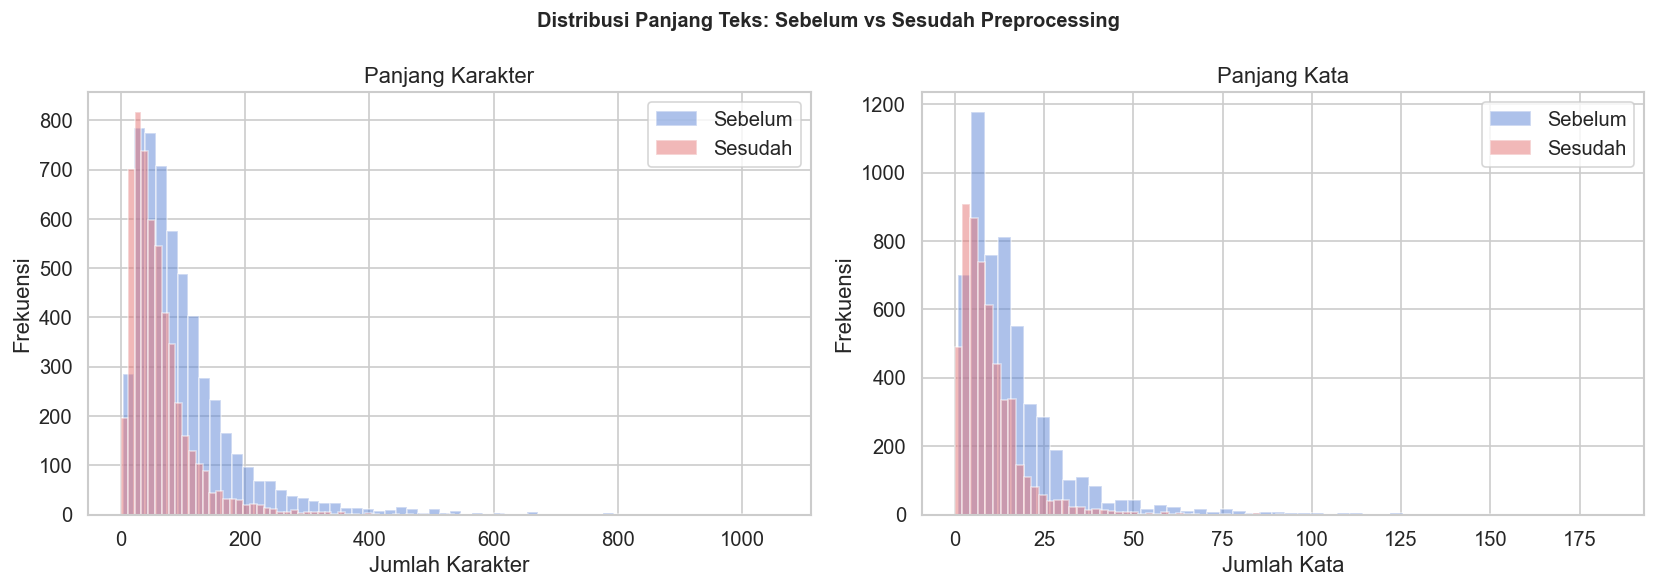

In [25]:
# ── Visualisasi perbandingan sebelum vs sesudah ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Panjang Teks: Sebelum vs Sesudah Preprocessing",
             fontsize=12, fontweight="bold")

# Karakter
axes[0].hist(df_clean["Customer Review"].str.len(), bins=60,
             alpha=0.5, label="Sebelum", color="#5C85D6")
axes[0].hist(df_clean["clean_char_len"], bins=60,
             alpha=0.5, label="Sesudah", color="#E57373")
axes[0].set_title("Panjang Karakter")
axes[0].set_xlabel("Jumlah Karakter")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()

# Kata
before_wl = df_clean["Customer Review"].str.split().str.len()
axes[1].hist(before_wl, bins=50, alpha=0.5, label="Sebelum", color="#5C85D6")
axes[1].hist(df_clean["clean_word_len"], bins=50,
             alpha=0.5, label="Sesudah", color="#E57373")
axes[1].set_title("Panjang Kata")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Frekuensi")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "11_before_after_preprocessing.png", bbox_inches="tight")
plt.show()

In [26]:
# ── Tampilkan 5 contoh before/after ──────────────────────────────────────
sample_comparison = df_clean[["Customer Review", "clean_review", "Sentiment", "Emotion"]].sample(
    5, random_state=RANDOM_SEED
).reset_index(drop=True)

pd.set_option("display.max_colwidth", 120)
print("\n📋 Contoh Before → After Preprocessing:")
sample_comparison


📋 Contoh Before → After Preprocessing:


,Customer Review,clean_review,Sentiment,Emotion
0,selalu terbaik. barang dan pelayannya memuaskan as always.,baik barang layan muas as always,Positive,Happy
1,packaging nya cuma plastik item itupun sobek pas baru diterima,packaging plastik item itu sobek pas terima,Negative,Sadness
2,obeng bintang nya kurang nyaman untuk dipegang. ujung obeng bintang mesti diratain dlu.. ada sisa potongan.,obeng bintang nyaman pegang ujung obeng bintang mesti diratain dlu sisa potong,Negative,Fear
3,Barang pesan 3 kg dikirim 1kg brengsek,barang pesan kg kirim kg brengsek,Negative,Anger
4,respon penjual cepat dan ramah,respons jual cepat ramah,Positive,Happy


## 3.6 WordCloud Pasca-Preprocessing

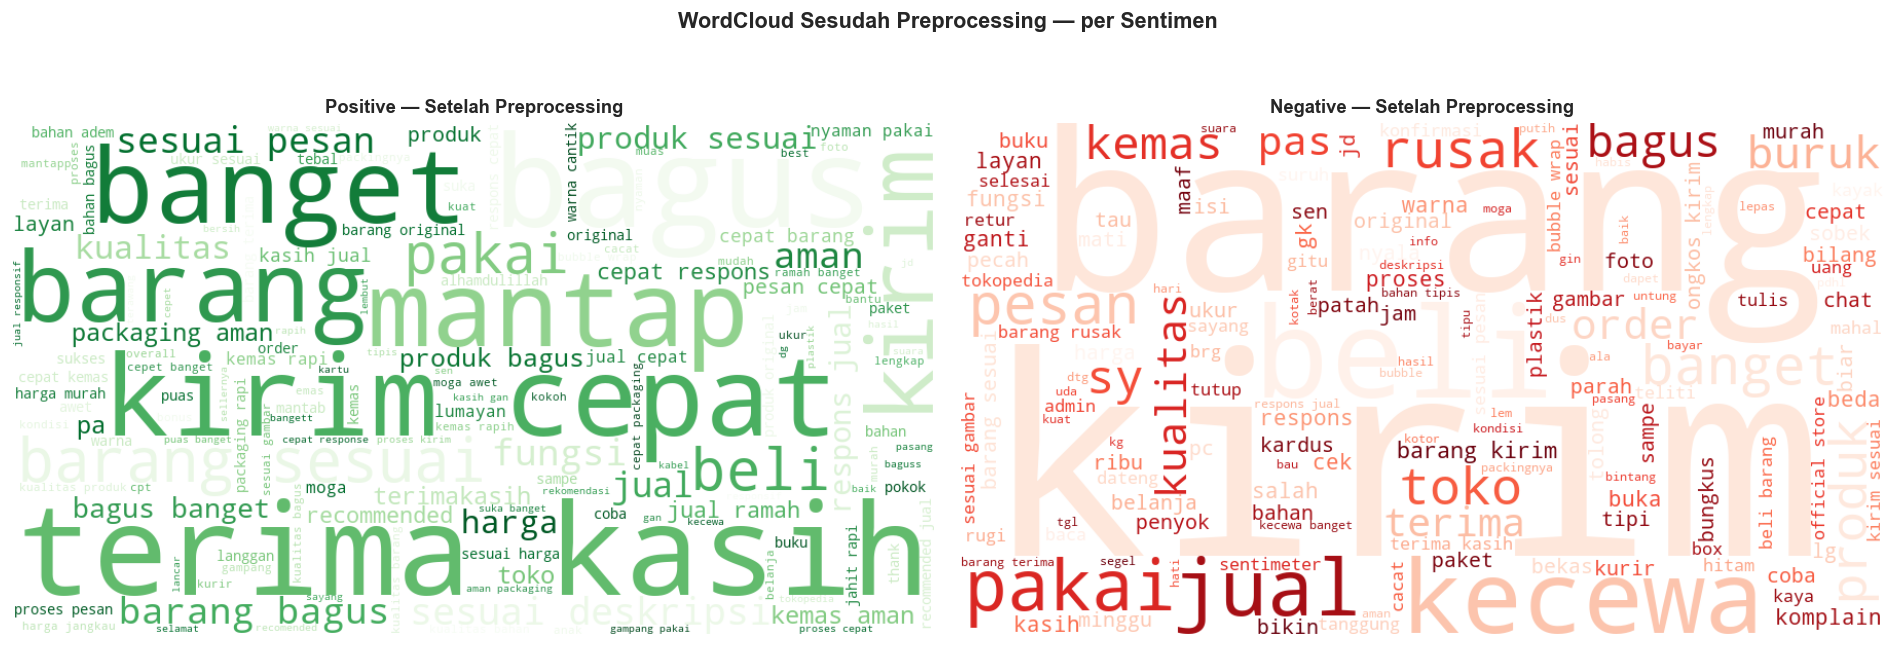

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("WordCloud Sesudah Preprocessing — per Sentimen",
             fontsize=13, fontweight="bold")

for ax, sent in zip(axes, ["Positive", "Negative"]):
    text = " ".join(
        df_clean[df_clean["Sentiment"] == sent]["clean_review"]
        .dropna().astype(str)
    )
    if text.strip():
        wc = WordCloud(
            width=900, height=500, background_color="white",
            max_words=150, colormap=SENT_CMAP[sent],
            random_state=RANDOM_SEED
        ).generate(text)
        ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{sent} — Setelah Preprocessing", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "12_wordcloud_clean_sentiment.png", bbox_inches="tight")
plt.show()

## 3.7 Label Encoding

In [28]:
# ── Encode label untuk keperluan modeling ────────────────────────────────
SENTIMENT_MAP = {"Positive": 1, "Negative": 0}
EMOTION_MAP   = {"Happy": 0, "Sadness": 1, "Fear": 2, "Love": 3, "Anger": 4}

df_clean["sentiment_label"] = df_clean["Sentiment"].map(SENTIMENT_MAP)
df_clean["emotion_label"]   = df_clean["Emotion"].map(EMOTION_MAP)

# Hapus baris dengan label kosong (hasil NaN mapping jika ada nilai tak terduga)
df_clean.dropna(subset=["sentiment_label", "emotion_label"], inplace=True)
df_clean["sentiment_label"] = df_clean["sentiment_label"].astype(int)
df_clean["emotion_label"]   = df_clean["emotion_label"].astype(int)

print("Label encoding mapping:")
print(f"  Sentimen : {SENTIMENT_MAP}")
print(f"  Emosi    : {EMOTION_MAP}")
print(f"\nShape final: {df_clean.shape}")
df_clean[["Customer Review", "clean_review", "Sentiment",
          "sentiment_label", "Emotion", "emotion_label"]].head(5)

Label encoding mapping:
  Sentimen : {'Positive': 1, 'Negative': 0}
  Emosi    : {'Happy': 0, 'Sadness': 1, 'Fear': 2, 'Love': 3, 'Anger': 4}

Shape final: (5391, 15)


,Customer Review,clean_review,Sentiment,sentiment_label,Emotion,emotion_label
0,Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah,alhamdulillah fungsi packaging aman respons cepat ramah jual kurir amanah,Positive,1,Happy,0
1,"barang bagus dan respon cepat, harga bersaing dengan yg lain.",barang bagus respons cepat harga saing,Positive,1,Happy,0
2,"barang bagus, berfungsi dengan baik, seler ramah, pengiriman cepat",barang bagus fungsi seler ramah kirim cepat,Positive,1,Happy,0
3,bagus sesuai harapan penjual nya juga ramah. trimakasih pelapak ??,bagus sesuai harap jual ramah trimakasih lapak,Positive,1,Happy,0
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi dengan Baik",barang bagus emas aman fungsi,Positive,1,Happy,0


## 3.8 Export ke CSV

In [29]:
# ── Kolom yang akan disimpan ──────────────────────────────────────────────
EXPORT_COLS = [
    "Category", "Product Name", "Location",
    "Price", "Overall Rating", "Number Sold",
    "Customer Rating",
    "Customer Review",       # Teks asli (untuk audit)
    "clean_review",          # Teks bersih (untuk fitur model)
    "Sentiment",             # Label teks
    "sentiment_label",       # Label numerik  (0=Negative, 1=Positive)
    "Emotion",               # Label teks
    "emotion_label",         # Label numerik
]

df_export = df_clean[EXPORT_COLS].reset_index(drop=True)

# ── Simpan ────────────────────────────────────────────────────────────────
df_export.to_csv(CLEAN_PATH, index=False, encoding="utf-8-sig")

file_size_kb = CLEAN_PATH.stat().st_size / 1024
print("=" * 55)
print("         ✅  EXPORT SELESAI")
print("=" * 55)
print(f"  Path       : {CLEAN_PATH.resolve()}")
print(f"  Baris      : {len(df_export):,}")
print(f"  Kolom      : {len(df_export.columns)}")
print(f"  Ukuran     : {file_size_kb:.1f} KB")
print(f"  Encoding   : UTF-8 with BOM (utf-8-sig)")
print("=" * 55)

         ✅  EXPORT SELESAI
  Path       : D:\pba2026-crazyrichteam\data\clean\cleaned_dataset.csv
  Baris      : 5,391
  Kolom      : 13
  Ukuran     : 1543.0 KB
  Encoding   : UTF-8 with BOM (utf-8-sig)


In [30]:
# ── Verifikasi: baca kembali CSV yang diekspor ────────────────────────────
df_verify = pd.read_csv(CLEAN_PATH, encoding="utf-8-sig")
print(f"Verifikasi — shape         : {df_verify.shape}")
print(f"Verifikasi — kolom         : {df_verify.columns.tolist()}")
print(f"Verifikasi — missing values: {df_verify.isnull().sum().sum()}")
df_verify.head(3)

Verifikasi — shape         : (5391, 13)
Verifikasi — kolom         : ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Customer Rating', 'Customer Review', 'clean_review', 'Sentiment', 'sentiment_label', 'Emotion', 'emotion_label']
Verifikasi — missing values: 5


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Customer Rating,Customer Review,clean_review,Sentiment,sentiment_label,Emotion,emotion_label
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G Handheld PC Android TV,Jakarta Utara,53500,4.9,5449,5,Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah,alhamdulillah fungsi packaging aman respons cepat ramah jual kurir amanah,Positive,1,Happy,0
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 ORIGINAL + BONUS,Kota Tangerang Selatan,72000,4.9,2359,5,"barang bagus dan respon cepat, harga bersaing dengan yg lain.",barang bagus respons cepat harga saing,Positive,1,Happy,0
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,5,"barang bagus, berfungsi dengan baik, seler ramah, pengiriman cepat",barang bagus fungsi seler ramah kirim cepat,Positive,1,Happy,0
